# CNN-BiLSTM-Attention Architecture Diagram (PlotNeuralNet)

## How PlotNeuralNet works

The library provides **3 TikZ shapes**:

| Shape | Use case | Visual |
|-------|----------|--------|
| `Box` | Single layer (Conv, Pool, FC, etc.) | 3D cuboid |
| `RightBandedBox` | Multi-sub-layer block (Conv+ReLU, repeated convs) | 3D cuboid with colored right-band accent |
| `Ball` | Elementwise ops (Sum, Product) | Sphere |

### Key parameters for `Box` / `RightBandedBox`:
- **`height`** — vertical size of the 3D block (front face height)
- **`depth`** — horizontal size of the front face (the "into-screen" axis)
- **`width`** — thickness of the block (left-to-right in the render direction)
- **`zlabel`** — text printed on the depth axis (spatial dimension label)
- **`xlabel`** — text printed on the width (top) axis (number of filters)
- **`ylabel`** — text printed on the height axis
- **`caption`** — text below the block
- **`fill`** — color of the block
- **`opacity`** — transparency
- **`offset`** — (x,y,z) shift relative to anchor
- **`to`** — anchor point to position relative to

### Conventions from examples:

| Example | height/depth scaling | width scaling |
|---------|---------------------|---------------|
| **AlexNet** | `height=depth = spatial_dim / 5` (224→44.8, 55→11, 27→5.4, 13→2.6) | `width = n_filters / 20` (96→4.8, 256→12.8, 384→19.2) |
| **LeNet** | `height=depth = spatial_dim` (32→32, 28→28, 14→14, 10→10, 5→5) | `width = n_filters` (1, 6, 16) |
| **VGG16** | `height=depth` decreases per pool (40→35→30→23→15→10→3) | `width = n_filters / 50` approx |
| **U-Net** | `height=depth` (40→32→25→16→8→16→25→32→40) | `width = n_filters / 28` approx |

### Key patterns:
1. **height = depth** (symmetric square cross-section) in ALL examples
2. **height/depth shrinks after pooling** — shows spatial dimension reduction
3. **width grows with more filters** — shows increasing representation capacity
4. **Pool** layers use `opacity=0.5` and `width=1` (thin transparent slab)
5. **RightBandedBox** used for Conv+ReLU pairs — `width={2,2}` draws 2 sub-blocks
6. **FC layers** in AlexNet/VGG: `height=1-3, depth=large` (tall thin slab, rotated)
7. **Connections** drawn with `\draw [connection] (A-east) -- node {\midarrow} (B-west);`
8. **Skip connections** (U-Net) use `copyconnection` style going over the top

## Generate Our Architecture

CNN-BiLSTM-Attention (210,818 params):
- Input: 4 channels × 2048 timesteps (1D signal, not 2D image)
- Conv1D Stem: 64 filters, k=7
- ResDSBlock ×2: depthwise-separable conv, k=9, residual skip
- MaxPool: stride=8 → 2048→256 timesteps
- BiLSTM: 64 hidden → 128 output per timestep
- Transformer Block: 4-head self-attention, FFN(128→256→128)
- Global Average Pooling → Dense(128→2)

### Scaling decisions:
Since this is a **1D** model (no 2D spatial dims), we adapt the convention:
- **height = depth** → proportional to **sequence length** (keeps symmetric look)
- **width** → proportional to **number of channels/features**
- Sequence: 2048 → height=40, after pool 256 → height=20, GAP → height=3
- Channels: 4→width=0.5, 64→width=3, 128→width=5

In [1]:
import sys, os
sys.path.append('PlotNeuralNet')
from pycore.tikzeng import *

In [2]:
arch = [
    to_head('PlotNeuralNet'),
    to_cor(),
    to_begin(),

    # === INPUT ===
    # 4 channels × 2048 timesteps
    # Using AlexNet convention: height=depth=spatial/50 → 2048/50≈40
    # width = n_filters/20 → 4/20 = 0.2 (use 0.5 minimum for visibility)
    to_Conv(
        name="input",
        s_filer="",
        n_filer=4,
        offset="(0,0,0)",
        to="(0,0,0)",
        width=0.5,
        height=40,
        depth=40,
        caption="Input"
    ),

    # === CONV1D STEM ===
    # 64 filters, same sequence length (2048)
    # width = 64/20 = 3.2 ≈ 3
    to_Conv(
        name="stem",
        s_filer="",
        n_filer=64,
        offset="(2,0,0)",
        to="(input-east)",
        width=3,
        height=40,
        depth=40,
        caption="Conv1D Stem"
    ),
    to_connection("input", "stem"),

    # === ResDSBlock 1 ===
    # 64 filters, 2048 timesteps, DS-Conv + residual
    # Using RightBandedBox to show Conv+BN+GELU sub-layers
    to_Conv(
        name="res1",
        s_filer="",
        n_filer=64,
        offset="(1.5,0,0)",
        to="(stem-east)",
        width=3,
        height=40,
        depth=40,
        caption="ResDS$_1$"
    ),
    to_connection("stem", "res1"),

    # === ResDSBlock 2 ===
    to_Conv(
        name="res2",
        s_filer="",
        n_filer=64,
        offset="(1.5,0,0)",
        to="(res1-east)",
        width=3,
        height=40,
        depth=40,
        caption="ResDS$_2$"
    ),
    to_connection("res1", "res2"),

    # === MAXPOOL ===
    # stride=8: 2048 → 256 timesteps
    # height/depth shrink: 256/2048 * 40 = 5 → use 20 for visibility
    to_Pool(
        name="pool",
        offset="(0,0,0)",
        to="(res2-east)",
        width=1,
        height=20,
        depth=20,
        opacity=0.5,
        caption="MaxPool"
    ),

    # === BiLSTM ===
    # 256 timesteps, 128 features
    # height/depth = 20 (same as after pool)
    # width = 128/20 = 6.4 ≈ 6 (thicker — more features)
    to_Conv(
        name="lstm",
        s_filer="",
        n_filer=128,
        offset="(2,0,0)",
        to="(pool-east)",
        width=6,
        height=20,
        depth=20,
        caption="BiLSTM"
    ),
    to_connection("pool", "lstm"),

    # === TRANSFORMER (MHSA + FFN) ===
    # 256 timesteps, 128 features
    to_Conv(
        name="attn",
        s_filer="",
        n_filer=128,
        offset="(2,0,0)",
        to="(lstm-east)",
        width=6,
        height=20,
        depth=20,
        caption="MHSA+FFN"
    ),
    to_connection("lstm", "attn"),

    # === GLOBAL AVERAGE POOLING ===
    # 128 features, 1 timestep → collapse to vector
    to_Pool(
        name="gap",
        offset="(0,0,0)",
        to="(attn-east)",
        width=3,
        height=3,
        depth=3,
        opacity=0.5,
        caption="GAP"
    ),

    # === DENSE CLASSIFIER ===
    # FC layers in AlexNet/VGG: height=small, depth=large (tall thin bar)
    to_SoftMax(
        name="fc",
        s_filer=2,
        offset="(2,0,0)",
        to="(gap-east)",
        width=1.5,
        height=3,
        depth=15,
        caption="FC"
    ),
    to_connection("gap", "fc"),

    to_end()
]

to_generate(arch, 'cnn_bilstm_attn.tex')
print("Generated: cnn_bilstm_attn.tex")


\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{PlotNeuralNet/layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style={sloped,allow upside down},draw=\edgecolor,opacity=0.7]
\tikzstyle{copyconnection}=[ultra thick,every node/.style={sloped,allow upside down},draw={rgb:blue,4;red,1;green,1;black,3},opacity=0.7]


\pic[shift={(0,0,0)}] at (0,0,0) 
    {Box={
 

### Now add custom colors for different layer types

The default `\ConvColor` is used for all `to_Conv` blocks. Let's inject custom colors
directly into the `.tex` to distinguish CNN / RNN / Attention layers.

In [3]:
# Post-process the .tex file to add custom colors for LSTM and Attention blocks
with open('cnn_bilstm_attn.tex', 'r') as f:
    tex = f.read()

# Add custom color definitions after the default ones
color_defs = r"""
% Custom colors for hybrid architecture
\def\LstmColor{rgb:green,4;blue,1;white,3}
\def\AttnColor{rgb:red,3;magenta,2;white,4}
\def\InputColor{rgb:blue,1;white,8}
"""
tex = tex.replace(r'\def\SumColor{rgb:blue,5;green,15}',
                  r'\def\SumColor{rgb:blue,5;green,15}' + color_defs)

# Change fill color for specific blocks
# Input block → light blue
tex = tex.replace(
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\InputColor,'
)
# LSTM block → green
tex = tex.replace(
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\LstmColor,'
)
# Attention block → pink/red
tex = tex.replace(
    'name=attn,\n        caption=MHSA+FFN,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=attn,\n        caption=MHSA+FFN,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\AttnColor,'
)

with open('cnn_bilstm_attn.tex', 'w') as f:
    f.write(tex)

print("Colors updated in .tex file")
print("\nColor mapping:")
print("  Input      → light blue")
print("  Conv/ResDS → yellow-orange (default ConvColor)")
print("  Pool       → dark red (default PoolColor)")
print("  BiLSTM     → green")
print("  MHSA+FFN   → pink/red")
print("  FC/Softmax → purple (default SoftmaxColor)")

Colors updated in .tex file

Color mapping:
  Input      → light blue
  Conv/ResDS → yellow-orange (default ConvColor)
  Pool       → dark red (default PoolColor)
  BiLSTM     → green
  MHSA+FFN   → pink/red
  FC/Softmax → purple (default SoftmaxColor)


In [4]:
# Compile to PDF
import subprocess

result = subprocess.run(
    ['pdflatex', '-interaction=nonstopmode', 'cnn_bilstm_attn.tex'],
    capture_output=True, text=True, cwd=os.getcwd()
)

if 'Output written' in result.stdout:
    print("✓ PDF generated: cnn_bilstm_attn.pdf")
    # Convert to PNG for preview
    subprocess.run(
        ['pdftoppm', '-png', '-r', '250', 'cnn_bilstm_attn.pdf', 'cnn_bilstm_attn_preview'],
        cwd=os.getcwd()
    )
    print("✓ PNG preview: cnn_bilstm_attn_preview-1.png")
else:
    # Print last 20 lines of log for debugging
    print("ERROR — last lines of output:")
    print('\n'.join(result.stdout.split('\n')[-20:]))

✓ PDF generated: cnn_bilstm_attn.pdf
✓ PNG preview: cnn_bilstm_attn_preview-1.png


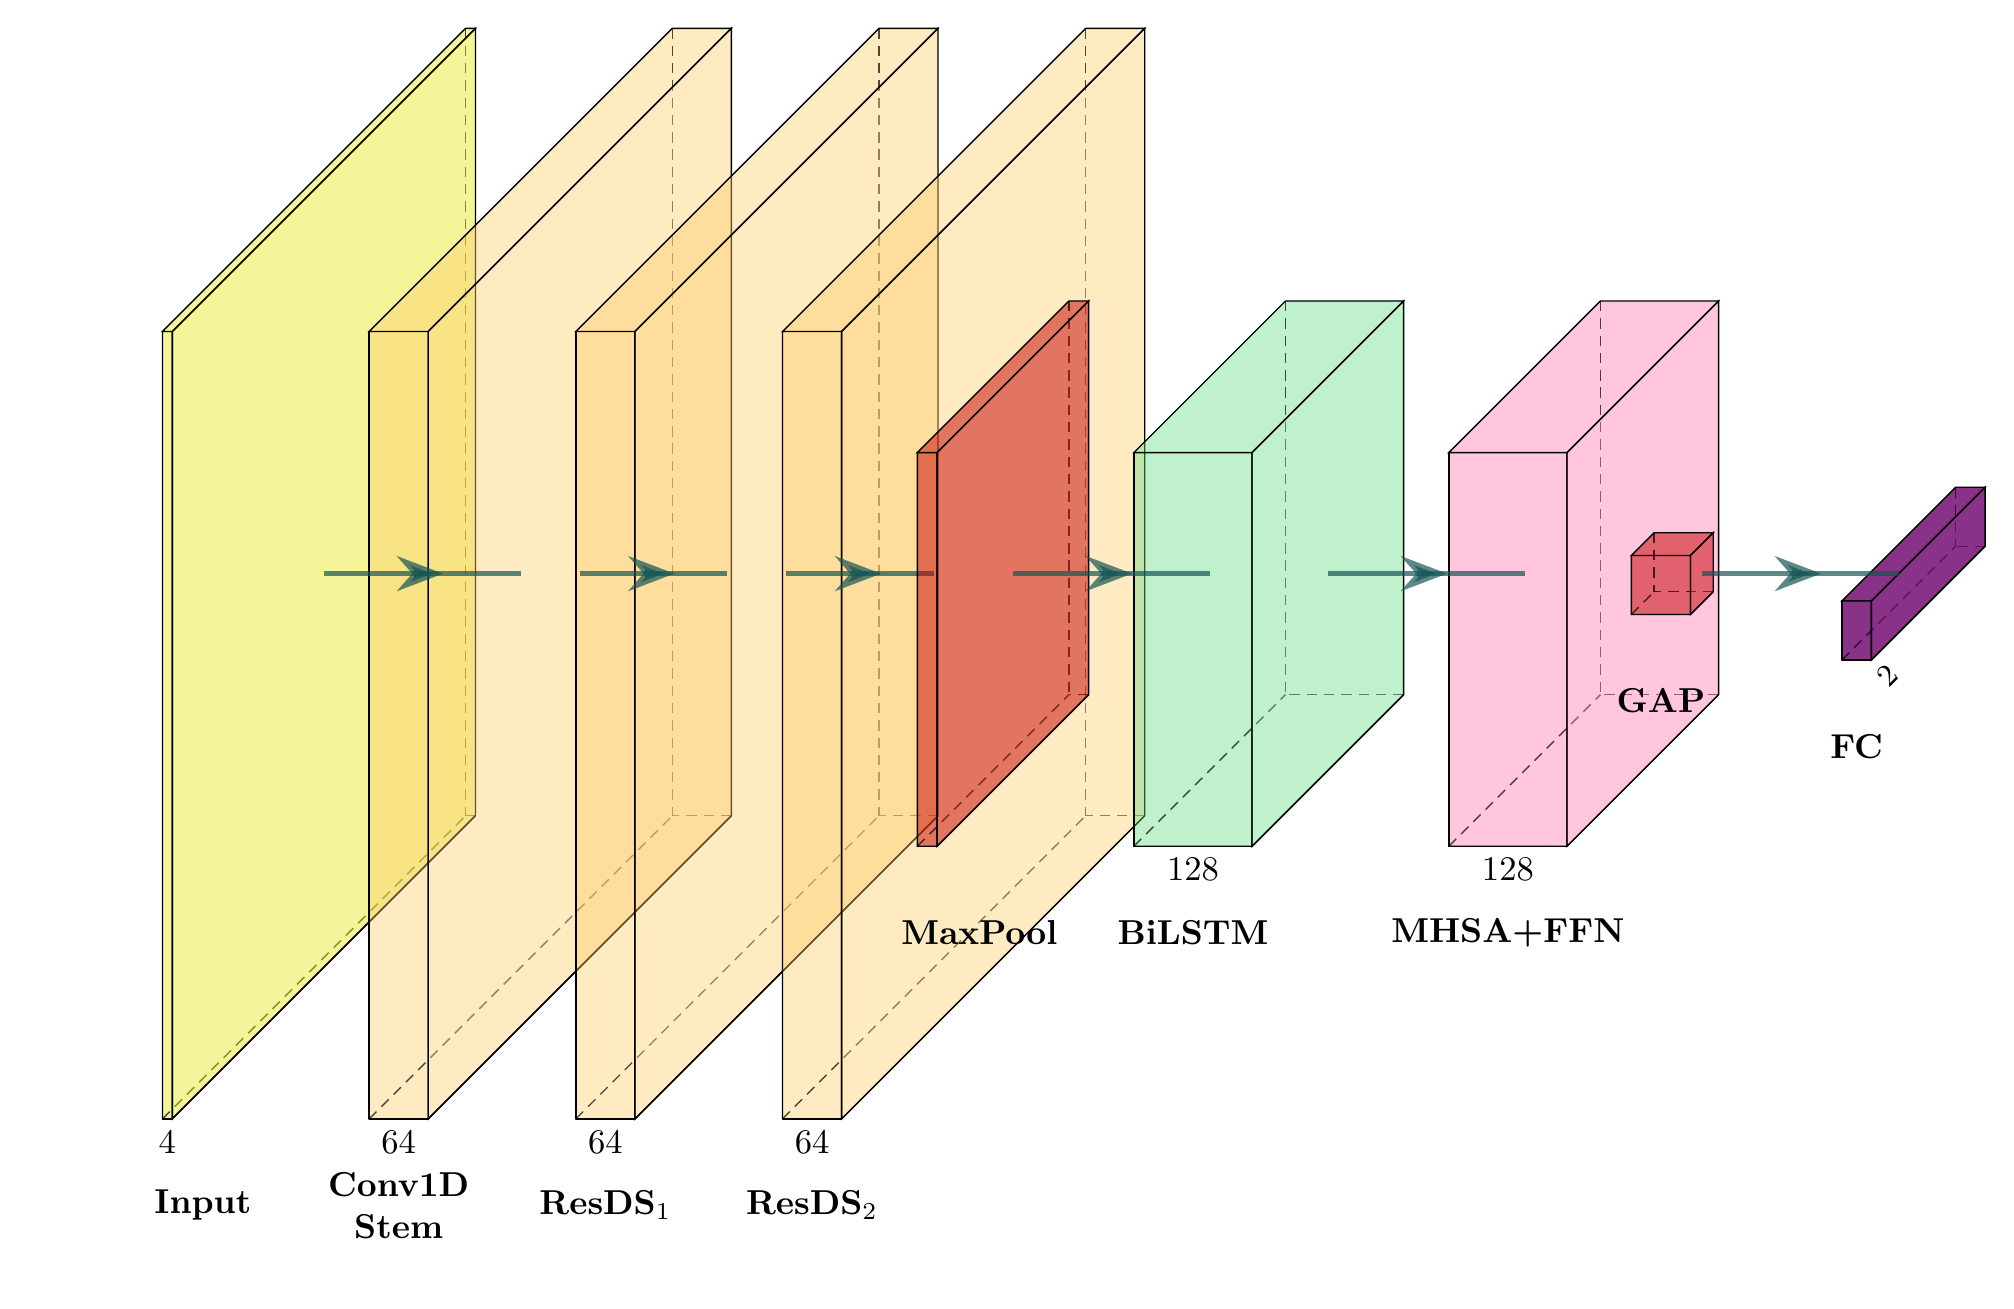

In [5]:
# Display the result
from IPython.display import Image, display
display(Image('cnn_bilstm_attn_preview-1.png'))